In [34]:
from __future__ import annotations

from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.style.use('ggplot')


In [35]:
if Path('data/output_log.csv').exists():
    PROJECT_ROOT = Path('.').resolve()
    DATA_PATH = PROJECT_ROOT / 'data' / 'output_log.csv'
elif Path('output_log.csv').exists():
    PROJECT_ROOT = Path('..').resolve()
    DATA_PATH = Path('output_log.csv').resolve()
else:
    raise FileNotFoundError('Khong tim thay output_log.csv. Hay chay notebook tu root project hoac tu thu muc data/.')

df = pd.read_csv(DATA_PATH)
df.head()


,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,estimate_time,predict_time,delta_time
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,144.0,153.0,141.879610
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,143.4,176.4,214.738806
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,144.6,174.6,131.112207
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,187.8,153.0,197.674791
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,133.8,174.6,191.282736


In [45]:
important = ['hour', 'estimate_time', 'predict_time', 'delta_time']

df_cop = df.copy()
df_cop = df_cop[important]

df_cop.head(20)

,hour,estimate_time,predict_time,delta_time
0,14,144.0,153.0,141.879610
1,16,143.4,176.4,214.738806
2,18,144.6,174.6,131.112207
3,14,187.8,153.0,197.674791
4,7,133.8,174.6,191.282736
5,12,139.8,145.8,151.191171
6,10,181.2,197.4,139.448080
7,6,128.4,166.8,192.903437
8,15,140.4,202.2,144.048183
9,16,144.6,176.4,127.109001


In [36]:
print(f'Dataset path: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing_values'))
display(df.nunique().to_frame('unique_values'))


Dataset path: D:\vinAI\GSM\Map\ETA-prediction\data\output_log.csv
Shape: 309 rows x 10 columns


,dtype
stationId,int64
destination_stationId,int64
hour,int64
lat,float64
lng,float64
destination_lat,float64
destination_lng,float64
estimate_time,float64
predict_time,float64
delta_time,float64


,missing_values
stationId,0
destination_stationId,0
hour,0
lat,0
lng,0
destination_lat,0
destination_lng,0
estimate_time,0
predict_time,0
delta_time,0


,unique_values
stationId,1
destination_stationId,1
hour,18
lat,1
lng,1
destination_lat,1
destination_lng,1
estimate_time,58
predict_time,17
delta_time,309


In [37]:
required_columns = {
    'stationId', 'destination_stationId', 'hour', 'lat', 'lng',
    'destination_lat', 'destination_lng', 'estimate_time','predict_time'
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df = df.copy()
numeric_columns = ['stationId', 'destination_stationId', 'hour', 'lat', 'lng', 'destination_lat', 'destination_lng', 'estimate_time', 'predict_time']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

if df[numeric_columns].isna().any().any():
    display(df[numeric_columns].isna().sum().to_frame('missing_after_numeric_cast'))
    raise ValueError('Co gia tri khong ep kieu numeric duoc trong cac cot bat buoc.')

if not df['hour'].between(0, 23).all():
    raise ValueError('Cot hour co gia tri nam ngoai khoang [0, 23].')

route_columns = ['stationId', 'destination_stationId', 'lat', 'lng', 'destination_lat', 'destination_lng']

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
stationId,309.0,1992.000000,0.000000e+00,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
destination_stationId,309.0,323.000000,0.000000e+00,323.000000,323.000000,323.000000,323.000000,323.000000
hour,309.0,13.223301,4.621938e+00,4.000000,8.000000,16.000000,17.000000,21.000000
lat,309.0,10.872419,1.779238e-15,10.872419,10.872419,10.872419,10.872419,10.872419
lng,309.0,106.768248,1.423391e-14,106.768248,106.768248,106.768248,106.768248,106.768248
destination_lat,309.0,10.875454,3.558476e-15,10.875454,10.875454,10.875454,10.875454,10.875454
destination_lng,309.0,106.758689,0.000000e+00,106.758689,106.758689,106.758689,106.758689,106.758689
estimate_time,309.0,153.326214,1.712233e+01,118.800000,143.400000,144.600000,162.600000,191.400000
predict_time,309.0,172.972816,1.635915e+01,128.400000,165.600000,174.600000,176.400000,215.400000
delta_time,309.0,188.304376,7.680745e+01,74.199850,143.994139,170.172401,208.990548,891.276558


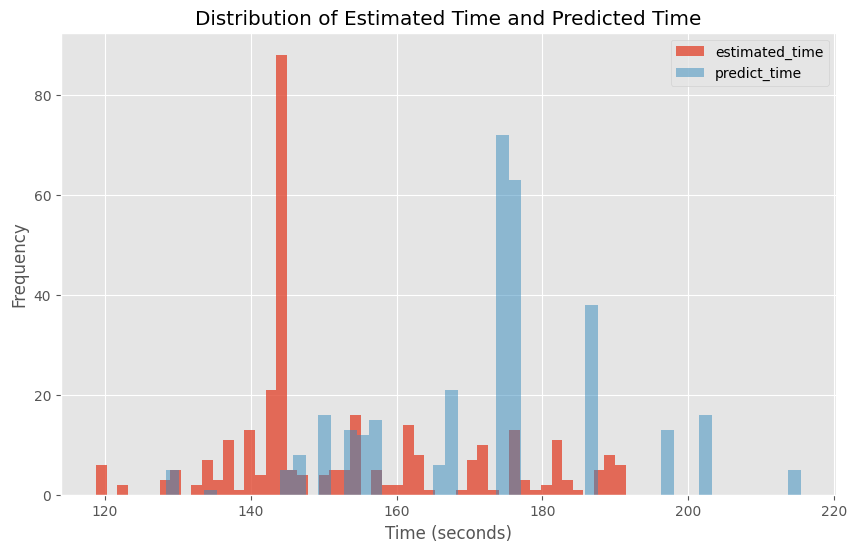

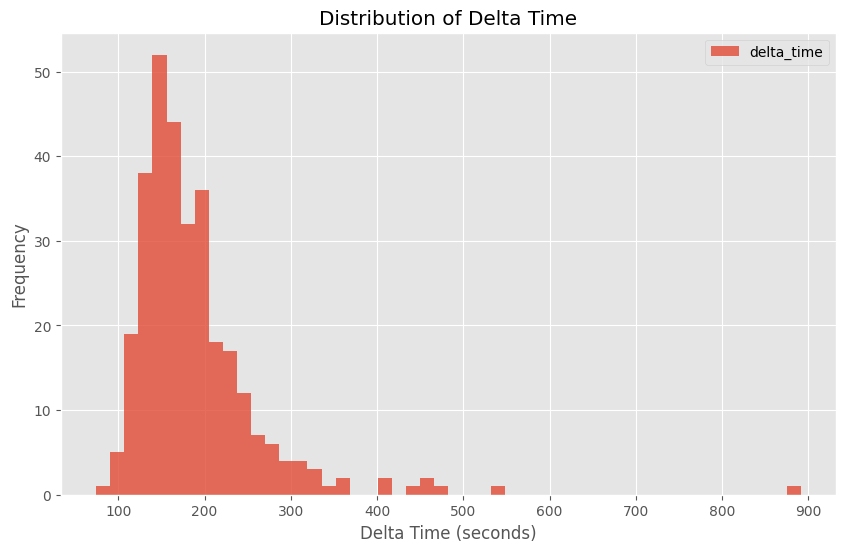

In [38]:
# ETA distribution estimated_time va predict_time (same plot, use different colors and transparency)
plt.figure(figsize=(10, 6))
plt.hist(df['estimate_time'], bins=50, alpha=0.8, label='estimated_time')
plt.hist(df['predict_time'], bins=50, alpha=0.5, label='predict_time')
plt.xlabel('Time (seconds)')   
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Time and Predicted Time')
plt.legend()
plt.show()

#delta_time distribution
plt.figure(figsize=(10, 6))
plt.hist(df['delta_time'], bins=50, alpha=0.8, label='delta_time')
plt.xlabel('Delta Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Delta Time')
plt.legend()
plt.show()

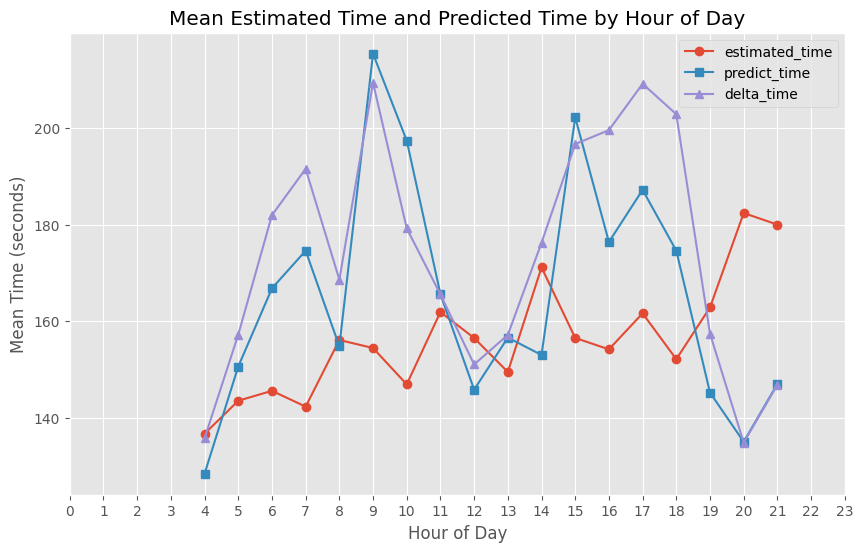

In [47]:
#ETA mean hourly of estimated_time and predict_time (same plot, use different colors and markers)
hourly_means = df.groupby('hour')[['estimate_time', 'predict_time', 'delta_time']].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(hourly_means['hour'], hourly_means['estimate_time'], marker='o', label='estimated_time')
plt.plot(hourly_means['hour'], hourly_means['predict_time'], marker='s', label='predict_time')
plt.plot(hourly_means['hour'], hourly_means['delta_time'], marker='^', label='delta_time')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Time (seconds)')
plt.title('Mean Estimated Time and Predicted Time by Hour of Day')
plt.xticks(range(0, 24))
plt.legend()
plt.show()


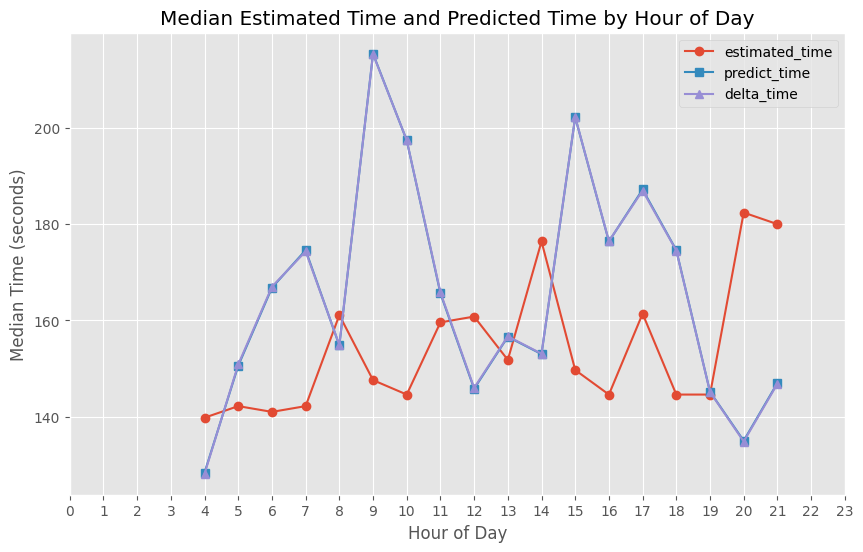

In [ ]:
#median hourly of estimated_time and predict_time (same plot, use different colors and markers)
hourly_medians = df.groupby('hour')[['estimate_time', 'predict_time', 'delta_time']].median().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(hourly_medians['hour'], hourly_medians['estimate_time'], marker='o', label='estimated_time')
plt.plot(hourly_medians['hour'], hourly_medians['predict_time'], marker='s', label='predict_time')
plt.xlabel('Hour of Day')
plt.ylabel('Median Time (seconds)')
plt.title('Median Estimated Time and Predicted Time by Hour of Day')
plt.xticks(range(0, 24))
plt.legend()
plt.show()